In [3]:
# GROUP 5 — BUSINESS CUSTOMER CLASSIFICATION
# Part 1: Problem Definition
# 1.1 Business Problem

# A company wants to identify customers who belong to a high-risk category. 
# The company can use information about customers such as their age, monthly
# spending, number of visits, and number of complaints to classify customers 
# into either:

# 0 → Low-risk customer
# 1 → High-risk customer

# The purpose of the Machine Learning model is to learn patterns from the 
# available customer data and predict whether a new customer is 
# likely to be classified as high-risk.

# 1.2 Machine Learning Problem

# This is a binary classification problem because the target 
# variable, high_risk, has only two possible classes: 0 and 1.

# 1.3 Target Variable

# Our target variable is:

# high_risk

# where:

# 0 = Low Risk
# 1 = High Risk

# 1.4 Input Features

# The initial features are:

#  Feature	Description
# customer_age:	Age of the customer

# monthly_spend:	Amount spent by the customer per month

# visits:	 Number of customer visits

# complaints: 	Number of complaints made by the customer

# customer_index:	 A calculated index based on the other customer variables

# 1.2 Business Question

# Which customer characteristics are most strongly associated with high-risk
# customers?

# Can a machine learning model reliably classify customers as 
# high-risk or low-risk?

# Which classification model performs best for this business problem?

# Does removing potentially target-derived features such as 
# customer_index affect model performance?

# Can the final model be used to classify new customers?

In [4]:
#Importing libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
#Part 2: Data Generation and Collection

# Set random seed for reproducibility
np.random.seed(99)

# Number of customers
n = 5000

# Generate customer variables
customer_age = np.random.randint(18, 80, n)

monthly_spend = np.random.lognormal(6, 2.5, n)

visits = np.random.randint(1, 80, n)

complaints = np.random.poisson(2, n)

# Create customer index
customer_index = (
    0.02 * customer_age
    + 0.00001 * monthly_spend
    + 0.04 * visits
    - 0.08 * complaints
)

# Create target variable
high_risk = (
    customer_index > np.median(customer_index)
).astype(int)

# Create DataFrame
df = pd.DataFrame({
    "customer_age": customer_age,
    "monthly_spend": monthly_spend,
    "visits": visits,
    "complaints": complaints,
    "customer_index": customer_index,
    "high_risk": high_risk
})

# Display first five rows
df.head(20)

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
0,19,526.195,13,1,0.825,0
1,53,973.513,19,3,1.590,0
2,75,718.761,73,3,4.187,1
3,58,5.983,26,1,2.120,0
4,27,6.980,29,5,1.300,0
5,58,483.184,19,2,1.765,0
6,36,284.544,54,4,2.563,1
7,22,"3,540.457",32,1,1.675,0
8,23,37.128,34,1,1.740,0
9,70,16.109,4,2,1.400,0


In [6]:
#Part 3: Save the Dataset

df.to_csv("group5_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [7]:
#Part 4: Load the Dataset
df = pd.read_csv("group5_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [8]:
df

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
0,19,526.195,13,1,0.825,0
1,53,973.513,19,3,1.590,0
2,75,718.761,73,3,4.187,1
3,58,5.983,26,1,2.120,0
4,27,6.980,29,5,1.300,0
...,...,...,...,...,...,...
4995,45,4.037,34,4,1.940,0
4996,26,4.640,54,4,2.360,0
4997,24,"5,072.104",38,5,1.651,0
4998,42,"1,237.474",74,2,3.652,1


In [9]:
df.head(10)

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
0,19,526.195,13,1,0.825,0
1,53,973.513,19,3,1.590,0
2,75,718.761,73,3,4.187,1
3,58,5.983,26,1,2.120,0
4,27,6.980,29,5,1.300,0
5,58,483.184,19,2,1.765,0
6,36,284.544,54,4,2.563,1
7,22,"3,540.457",32,1,1.675,0
8,23,37.128,34,1,1.740,0
9,70,16.109,4,2,1.400,0


In [10]:
#Part 5: Preserve the Raw Dataset
raw_df = df.copy()
raw_df.to_csv("group5_dataset_raw.csv", index=False)

print("Raw dataset preserved successfully.")

Raw dataset preserved successfully.


In [11]:
#Part 6: Data Understanding

#Display the First Five Rows
df.head(10)

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
0,19,526.195,13,1,0.825,0
1,53,973.513,19,3,1.590,0
2,75,718.761,73,3,4.187,1
3,58,5.983,26,1,2.120,0
4,27,6.980,29,5,1.300,0
5,58,483.184,19,2,1.765,0
6,36,284.544,54,4,2.563,1
7,22,"3,540.457",32,1,1.675,0
8,23,37.128,34,1,1.740,0
9,70,16.109,4,2,1.400,0


In [12]:
#Display the Last Five Rows
df.tail()

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
4995,45,4.037,34,4,1.940,0
4996,26,4.640,54,4,2.360,0
4997,24,"5,072.104",38,5,1.651,0
4998,42,"1,237.474",74,2,3.652,1
4999,58,289.730,47,1,2.963,1


In [13]:
#Part 7: Dataset Shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5000
Number of columns: 6


In [14]:
#Part 8: Column Names
print(df.columns.tolist())

['customer_age', 'monthly_spend', 'visits', 'complaints', 'customer_index', 'high_risk']


In [15]:
#Part 9: Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_age    5000 non-null   int64  
 1   monthly_spend   5000 non-null   float64
 2   visits          5000 non-null   int64  
 3   complaints      5000 non-null   int64  
 4   customer_index  5000 non-null   float64
 5   high_risk       5000 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 234.5 KB


In [16]:
#Part 10: Statistical Summary
df.describe()

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
count,"5,000.000","5,000.000","5,000.000","5,000.000","5,000.000","5,000.000"
mean,48.447,"7,946.089",39.903,2.023,2.483,0.500
std,17.829,"44,833.530",22.895,1.427,1.078,0.500
min,18.000,0.069,1.000,0.000,0.000,0.000
25%,33.000,70.110,20.000,1.000,1.666,0.000
50%,49.000,396.835,40.000,2.000,2.481,0.500
75%,63.000,"2,287.650",60.000,3.000,3.261,1.000
max,79.000,"1,102,074.941",79.000,10.000,13.761,1.000


In [17]:
#Part 11: Target Variable
df["high_risk"].unique()

array([0, 1])

In [18]:
#Part 12: Target Distribution
df["high_risk"].value_counts(normalize=True) * 100

high_risk
0   50.000
1   50.000
Name: proportion, dtype: float64

In [19]:
#Part 13: Basic Data Quality Check

df.isnull().sum()

customer_age      0
monthly_spend     0
visits            0
complaints        0
customer_index    0
high_risk         0
dtype: int64

In [20]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [21]:
#Part 14: Check Invalid Values
print("Age below 18:", (df["customer_age"] < 18).sum())

print("Negative spending:", (df["monthly_spend"] < 0).sum())

print("Negative visits:", (df["visits"] < 0).sum())

print("Negative complaints:", (df["complaints"] < 0).sum())

Age below 18: 0
Negative spending: 0
Negative visits: 0
Negative complaints: 0


In [22]:
#Part 15: Check Unique Values
for column in df.columns:
    print(column, ":", df[column].nunique(), "unique values")

customer_age : 62 unique values
monthly_spend : 5000 unique values
visits : 79 unique values
complaints : 11 unique values
customer_index : 5000 unique values
high_risk : 2 unique values


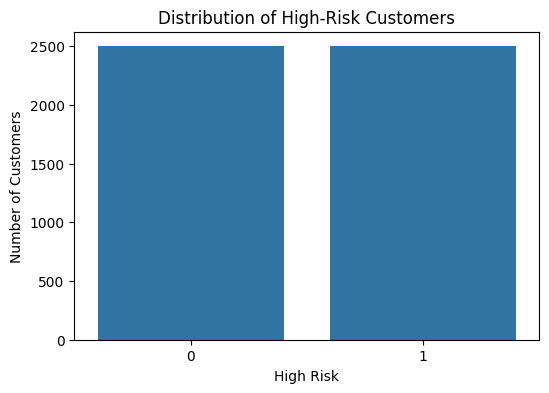

In [24]:
# #Part 17: Exploratory Data Analysis (EDA)

# The purpose of EDA is to understand the distribution of the variables, 
# identify unusual observations, and investigate relationships between 
# the predictors and the target variable.


###Check the Distribution of the Target
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="high_risk")

plt.title("Distribution of High-Risk Customers")
plt.xlabel("High Risk")
plt.ylabel("Number of Customers")

plt.show()

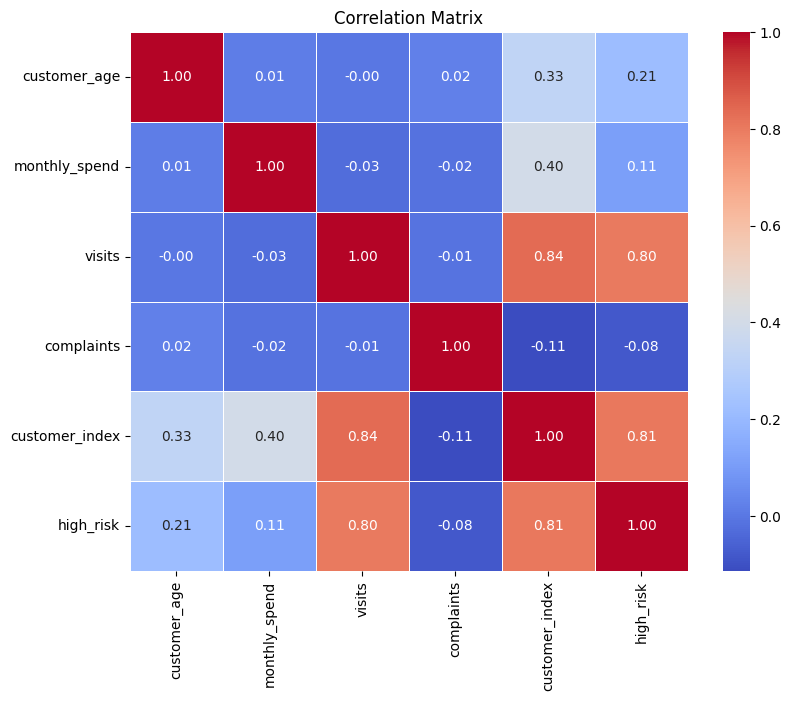

In [25]:
#Part 21: Correlation Matrix
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()



# What are we looking for?

# We want to identify:

# Strong positive relationships
    
# Strong negative relationships
    
# Weak relationships
    
# Relationships between predictors and high_risk

In [26]:
print(correlation.round(2).to_string())

                customer_age  monthly_spend  visits  complaints  customer_index  high_risk
customer_age           1.000          0.010  -0.000       0.020           0.330      0.210
monthly_spend          0.010          1.000  -0.030      -0.020           0.400      0.110
visits                -0.000         -0.030   1.000      -0.010           0.840      0.800
complaints             0.020         -0.020  -0.010       1.000          -0.110     -0.080
customer_index         0.330          0.400   0.840      -0.110           1.000      0.810
high_risk              0.210          0.110   0.800      -0.080           0.810      1.000


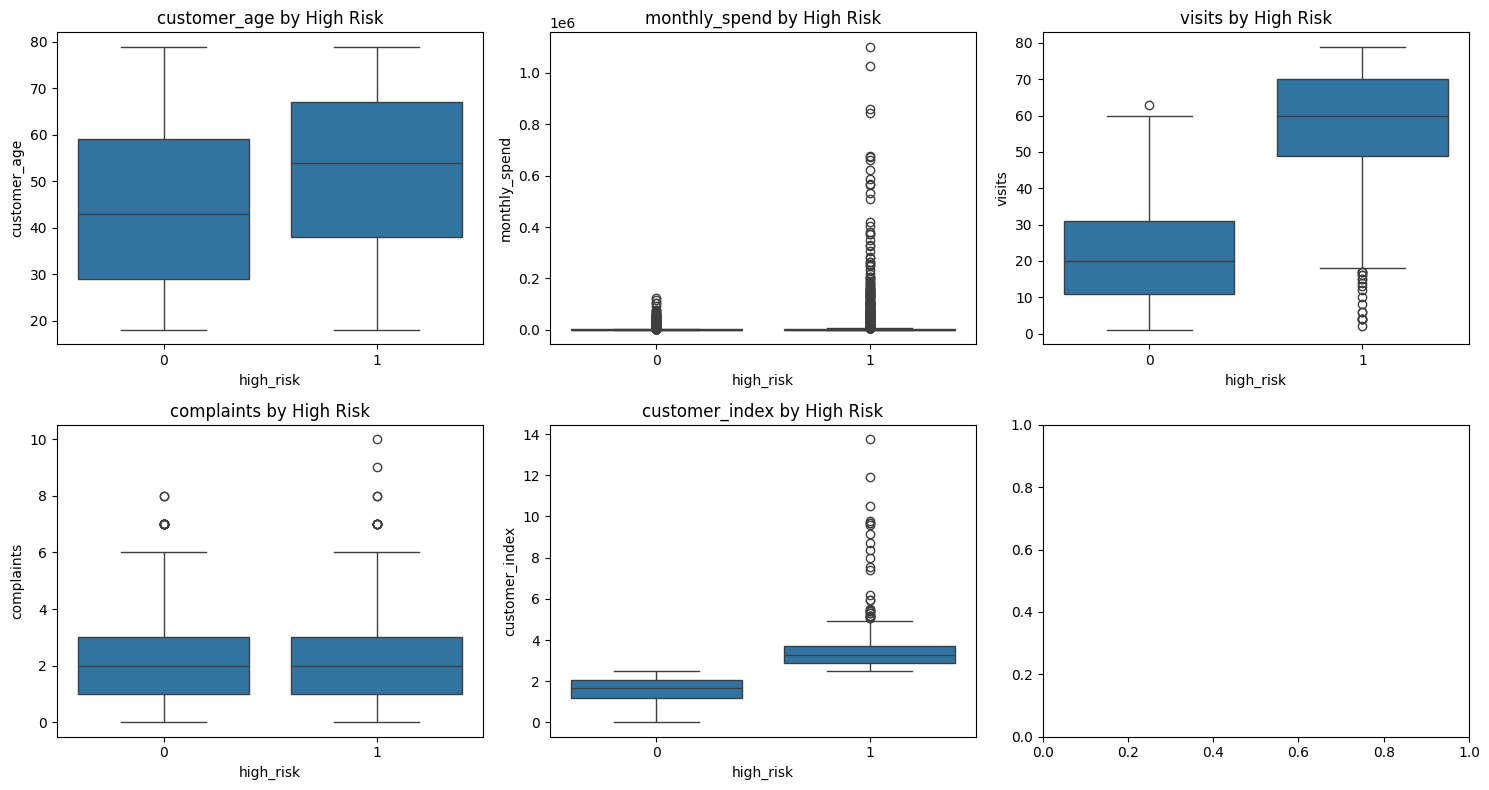

In [27]:
numeric_columns = [
    "customer_age",
    "monthly_spend",
    "visits",
    "complaints",
    "customer_index"
]


fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), numeric_columns):
    sns.boxplot(data=df, x="high_risk", y=col, ax=ax)
    ax.set_title(f"{col} by High Risk")

plt.tight_layout()
plt.show()

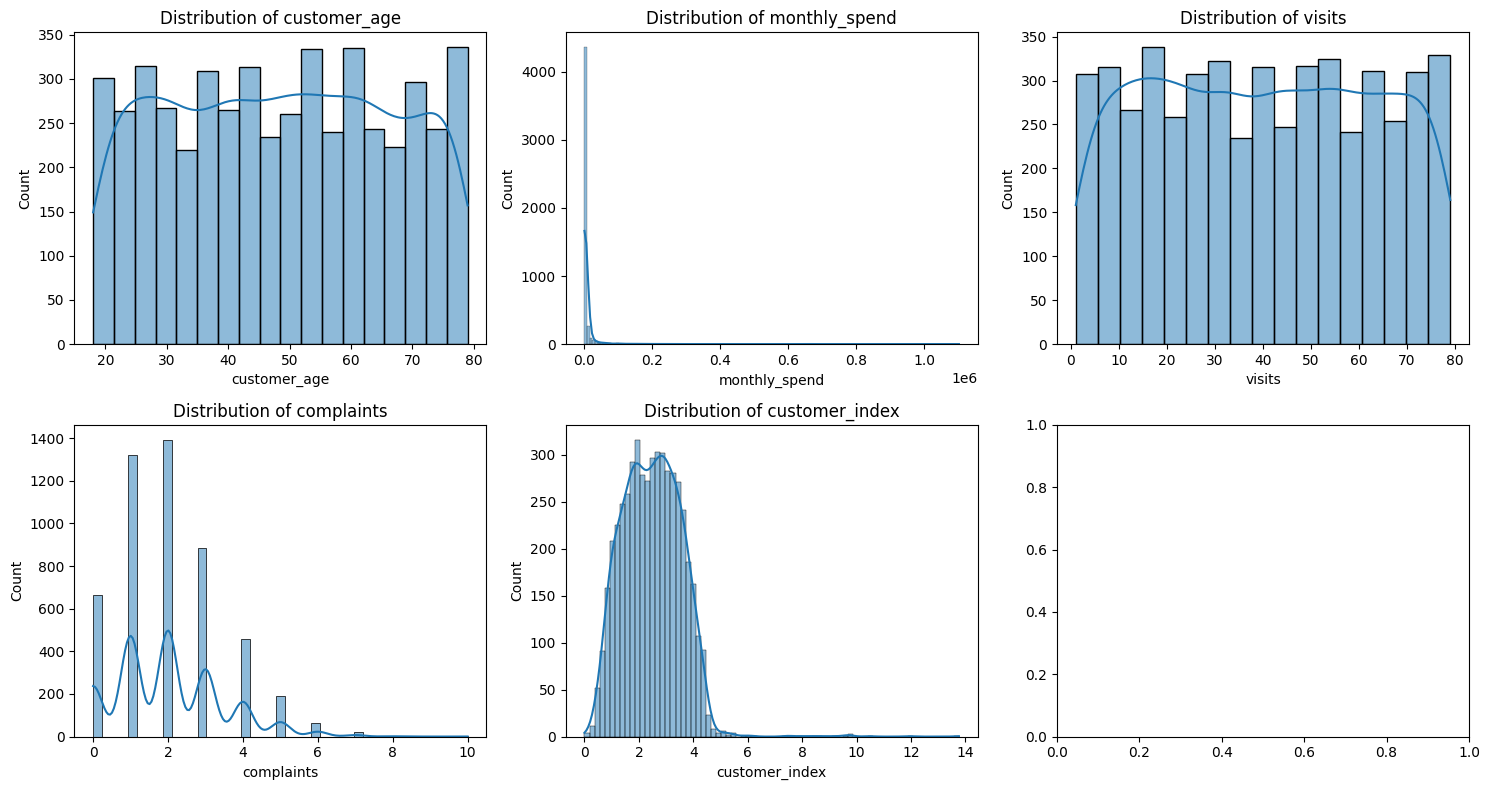

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), numeric_columns):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [29]:
df

,customer_age,monthly_spend,visits,complaints,customer_index,high_risk
0,19,526.195,13,1,0.825,0
1,53,973.513,19,3,1.590,0
2,75,718.761,73,3,4.187,1
3,58,5.983,26,1,2.120,0
4,27,6.980,29,5,1.300,0
...,...,...,...,...,...,...
4995,45,4.037,34,4,1.940,0
4996,26,4.640,54,4,2.360,0
4997,24,"5,072.104",38,5,1.651,0
4998,42,"1,237.474",74,2,3.652,1


In [30]:
#Leakage Inverstigatio
df[["customer_index", "high_risk"]].corr()



,customer_index,high_risk
customer_index,1.000,0.806
high_risk,0.806,1.000


In [31]:
df[[
    "customer_index",
    "high_risk"
]].head(20)

,customer_index,high_risk
0,0.825,0
1,1.590,0
2,4.187,1
3,2.120,0
4,1.300,0
5,1.765,0
6,2.563,1
7,1.675,0
8,1.740,0
9,1.400,0


In [32]:
#MACHINE LEARNING PART

#To CReate X and Y
X = df.drop("high_risk", axis=1)
y = df["high_risk"]

In [33]:
#To divide data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
#To conform split if it is correct
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

X_train: (4000, 5)
X_test: (1000, 5)

Training target:
high_risk
1   0.500
0   0.500
Name: proportion, dtype: float64

Testing target:
high_risk
0   0.500
1   0.500
Name: proportion, dtype: float64


In [35]:
#LOGISTIC REGRESSION MODAL

#EXPERIMENT A WITH customer_index

#Import library
from sklearn.linear_model import LogisticRegression

In [36]:
#Create model
logistic_model = LogisticRegression(max_iter=1000)

In [37]:
#TRain Model
logistic_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [38]:
#Prediction
y_pred = logistic_model.predict(X_test)

In [39]:
#Evaluate model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.998


In [40]:
#To compare test and Training performance
train_pred = logistic_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", accuracy)

Training Accuracy: 0.99925
Test Accuracy: 0.998


In [41]:
#EXPERIMENT B
#TO CREATE NEW FEATURE WITOUT ustomer_index

X_clean = df[
    [
        "customer_age",
        "monthly_spend",
        "visits",
        "complaints"
    ]
]

y = df["high_risk"]

In [42]:
#Split data Again
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
#Train LOgistic Regression
logistic_clean = LogisticRegression(max_iter=1000)

logistic_clean.fit(
    X_train_clean,
    y_train_clean
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [44]:
#Prediction
train_pred_clean = logistic_clean.predict(X_train_clean)

test_pred_clean = logistic_clean.predict(X_test_clean)

In [45]:
#Calculate Accurancy
train_accuracy_clean = accuracy_score(
    y_train_clean,
    train_pred_clean
)

test_accuracy_clean = accuracy_score(
    y_test_clean,
    test_pred_clean
)

print("Training Accuracy without customer_index:", train_accuracy_clean)
print("Test Accuracy without customer_index:", test_accuracy_clean)

Training Accuracy without customer_index: 0.99925
Test Accuracy without customer_index: 0.998


In [46]:
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Training Accuracy": [train_accuracy_clean],
    "Test Accuracy": [test_accuracy_clean]
})

results

,Model,Training Accuracy,Test Accuracy
0,Logistic Regression,0.999,0.998


#CONCLUSSION: 
The Logistic Regression model achieved unusually high performance,

with 99.925% training accuracy and 99.8% test accuracy. To investigate

whether customer_index was responsible for this performance, the feature
was removed and the model was retrained. The performance remained 
unchanged at 99.925% training accuracy and 99.8% test accuracy. 
This indicates that the unusually high performance is not primarily
caused by customer_index. Instead, it is largely due to the way the
target variable high_risk was constructed directly from the underlying
customer features.





In [48]:
#Correlation with Target

print(
    correlation["high_risk"]
    .sort_values(ascending=False)
)

high_risk         1.000
customer_index    0.806
visits            0.802
customer_age      0.214
monthly_spend     0.110
complaints       -0.082
Name: high_risk, dtype: float64


In [50]:
#Importing Metrix for Classifying the performance of LOgistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [51]:
#Calcurate Metrix

accuracy = accuracy_score(
    y_test_clean,
    test_pred_clean
)

precision = precision_score(
    y_test_clean,
    test_pred_clean
)

recall = recall_score(
    y_test_clean,
    test_pred_clean
)

f1 = f1_score(
    y_test_clean,
    test_pred_clean
)



print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.998
Precision: 0.998
Recall   : 0.998
F1 Score : 0.998


In [52]:
#Confussion Matrix

cm = confusion_matrix(
    y_test_clean,
    test_pred_clean
)

print(cm)

[[499   1]
 [  1 499]]


In [53]:
#Classification Report

print(
    classification_report(
        y_test_clean,
        test_pred_clean,
        target_names=["Low Risk", "High Risk"]
    )
)

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       500
   High Risk       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [54]:
#ROC_AUC

y_test_proba = logistic_clean.predict_proba(
    X_test_clean
)[:, 1]

auc = roc_auc_score(
    y_test_clean,
    y_test_proba
)

print("ROC-AUC:", auc)

ROC-AUC: 0.999992


#REPORT 
"The Logistic Regression model achieved exceptionally high performance on the test dataset, with 99.8% accuracy, precision, recall and F1-score, and an ROC-AUC of 0.999992. The confusion matrix showed only one false positive and one false negative. However, the unusually high performance should be interpreted cautiously because the target variable was synthetically generated from the same underlying features used for prediction."


In [55]:
print(df["monthly_spend"].describe())

count       5,000.000
mean        7,946.089
std        44,833.530
min             0.069
25%            70.110
50%           396.835
75%         2,287.650
max     1,102,074.941
Name: monthly_spend, dtype: float64


In [56]:
#MODAL B DECISION TREE

#Import Libraly
from sklearn.tree import DecisionTreeClassifier

In [57]:
#Create Model

tree_model = DecisionTreeClassifier(
    random_state=42
)

In [58]:
#Train Model

tree_model.fit(
    X_train_clean,
    y_train_clean
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [59]:
#Prediction
tree_train_pred = tree_model.predict(X_train_clean)

tree_test_pred = tree_model.predict(X_test_clean)

In [60]:
#Train and Test Accurancy

tree_train_accuracy = accuracy_score(
    y_train_clean,
    tree_train_pred
)

tree_test_accuracy = accuracy_score(
    y_test_clean,
    tree_test_pred
)

print("Training Accuracy:", tree_train_accuracy)
print("Test Accuracy:", tree_test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.964


In [61]:
#For All Metrics

tree_precision = precision_score(
    y_test_clean,
    tree_test_pred
)

tree_recall = recall_score(
    y_test_clean,
    tree_test_pred
)

tree_f1 = f1_score(
    y_test_clean,
    tree_test_pred
)

tree_proba = tree_model.predict_proba(
    X_test_clean
)[:, 1]

tree_auc = roc_auc_score(
    y_test_clean,
    tree_proba
)



print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1 Score:", tree_f1)
print("ROC-AUC:", tree_auc)

Precision: 0.9658634538152611
Recall: 0.962
F1 Score: 0.9639278557114228
ROC-AUC: 0.964


In [62]:
#Confussion Matrix

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_clean,
        tree_test_pred
    )
)


Confusion Matrix:
[[483  17]
 [ 19 481]]


In [63]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [64]:
#TRain
rf_model.fit(
    X_train_clean,
    y_train_clean
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [65]:
#Predictiion
rf_train_pred = rf_model.predict(
    X_train_clean
)

rf_test_pred = rf_model.predict(
    X_test_clean
)

In [66]:
#Accurancy

rf_train_accuracy = accuracy_score(
    y_train_clean,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test_clean,
    rf_test_pred
)

print("Training Accuracy:", rf_train_accuracy)
print("Test Accuracy:", rf_test_accuracy)

Training Accuracy: 1.0
Test Accuracy: 0.978


In [67]:
#Another metrix
rf_precision = precision_score(
    y_test_clean,
    rf_test_pred
)

rf_recall = recall_score(
    y_test_clean,
    rf_test_pred
)

rf_f1 = f1_score(
    y_test_clean,
    rf_test_pred
)



rf_proba = rf_model.predict_proba(
    X_test_clean
)[:, 1]

rf_auc = roc_auc_score(
    y_test_clean,
    rf_proba
)


print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_auc)

Precision: 0.9742063492063492
Recall: 0.982
F1 Score: 0.9780876494023905
ROC-AUC: 0.998676


In [68]:
#Confussion matrix

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_clean,
        rf_test_pred
    )
)


Confusion Matrix:
[[487  13]
 [  9 491]]


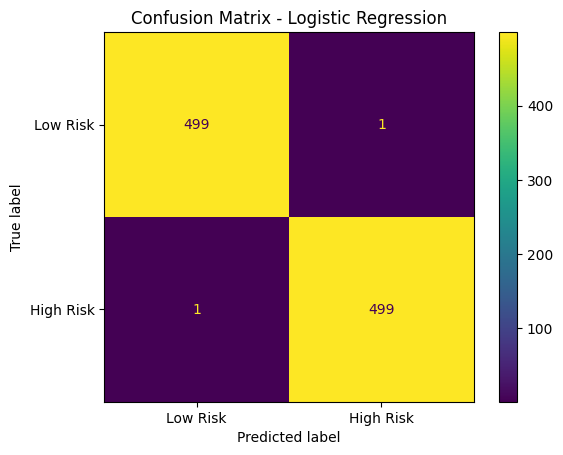

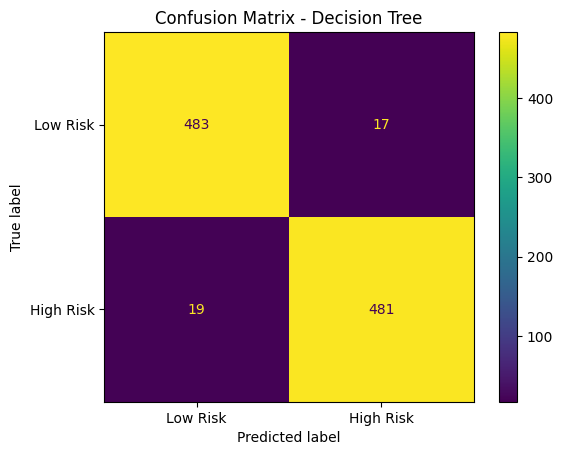

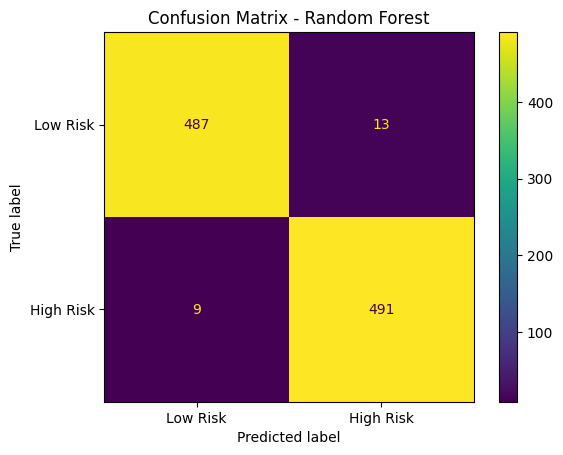

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": logistic_clean,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test_clean,
        y_test_clean,
        display_labels=["Low Risk", "High Risk"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

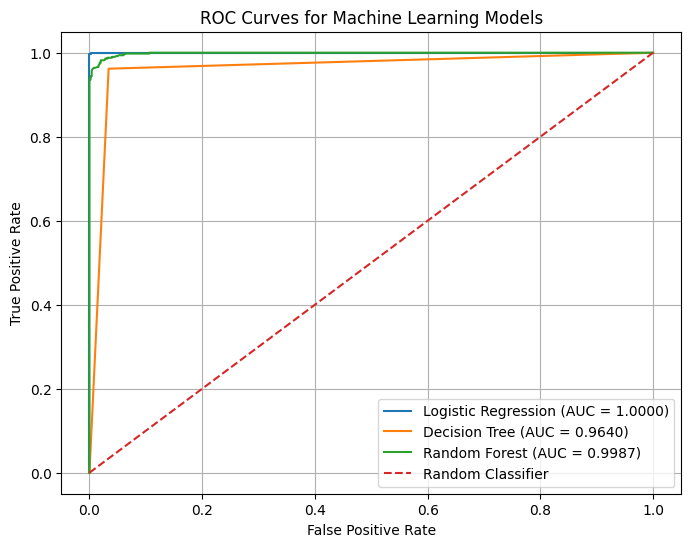

In [98]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():

    probabilities = model.predict_proba(
        X_test_clean
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test_clean,
        probabilities
    )

    auc = roc_auc_score(
        y_test_clean,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Machine Learning Models")
plt.legend()
plt.grid()

plt.show()

In [69]:
#Model Comaprizon

# Logistic Regression predictions
logistic_train_pred = logistic_clean.predict(X_train_clean)
logistic_test_pred = logistic_clean.predict(X_test_clean)

# Decision Tree predictions
tree_train_pred = tree_model.predict(X_train_clean)
tree_test_pred = tree_model.predict(X_test_clean)

# Random Forest predictions
rf_train_pred = rf_model.predict(X_train_clean)
rf_test_pred = rf_model.predict(X_test_clean)

In [70]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# =========================
# 1. Logistic Regression
# =========================

logistic_train_accuracy = accuracy_score(
    y_train_clean,
    logistic_train_pred
)

logistic_test_accuracy = accuracy_score(
    y_test_clean,
    logistic_test_pred
)

logistic_precision = precision_score(
    y_test_clean,
    logistic_test_pred
)

logistic_recall = recall_score(
    y_test_clean,
    logistic_test_pred
)

logistic_f1 = f1_score(
    y_test_clean,
    logistic_test_pred
)

logistic_proba = logistic_clean.predict_proba(
    X_test_clean
)[:, 1]

logistic_auc = roc_auc_score(
    y_test_clean,
    logistic_proba
)


# =========================
# 2. Decision Tree
# =========================

tree_train_accuracy = accuracy_score(
    y_train_clean,
    tree_train_pred
)

tree_test_accuracy = accuracy_score(
    y_test_clean,
    tree_test_pred
)

tree_precision = precision_score(
    y_test_clean,
    tree_test_pred
)

tree_recall = recall_score(
    y_test_clean,
    tree_test_pred
)

tree_f1 = f1_score(
    y_test_clean,
    tree_test_pred
)

tree_proba = tree_model.predict_proba(
    X_test_clean
)[:, 1]

tree_auc = roc_auc_score(
    y_test_clean,
    tree_proba
)


# =========================
# 3. Random Forest
# =========================

rf_train_accuracy = accuracy_score(
    y_train_clean,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test_clean,
    rf_test_pred
)

rf_precision = precision_score(
    y_test_clean,
    rf_test_pred
)

rf_recall = recall_score(
    y_test_clean,
    rf_test_pred
)

rf_f1 = f1_score(
    y_test_clean,
    rf_test_pred
)

rf_proba = rf_model.predict_proba(
    X_test_clean
)[:, 1]

rf_auc = roc_auc_score(
    y_test_clean,
    rf_proba
)


# =========================
# 4. Create comparison table
# =========================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Training Accuracy": [
        logistic_train_accuracy,
        tree_train_accuracy,
        rf_train_accuracy
    ],

    "Test Accuracy": [
        logistic_test_accuracy,
        tree_test_accuracy,
        rf_test_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        rf_auc
    ]
})


# =========================
# 5. Calculate accuracy gap
# =========================

comparison["Accuracy Gap"] = (
    comparison["Training Accuracy"]
    - comparison["Test Accuracy"]
)


# =========================
# 6. Convert to percentages
# =========================

metric_columns = [
    "Training Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Accuracy Gap"
]

comparison[metric_columns] = (
    comparison[metric_columns] * 100
).round(2)


# Display result
comparison

,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Accuracy Gap
0,Logistic Regression,99.920,99.800,99.800,99.800,99.800,100.000,0.120
1,Decision Tree,100.000,96.400,96.590,96.200,96.390,96.400,3.600
2,Random Forest,100.000,97.800,97.420,98.200,97.810,99.870,2.200


#FINAL TAKEAWAY:The experiment demonstrates that Logistic Regression achieved the strongest overall performance for the Business Customer Classification task. However, the extremely high performance is partly explained by the synthetic way in which high_risk was constructed. Therefore, the model should not be considered automatically reliable for real-world deployment without validation on genuine customer data.

In [71]:
import joblib

# Save model
joblib.dump(logistic_clean, "logistic_regression_model.pkl")

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!
